# Tiny FDN Reverbs: How Matrix Structure and Delay Arithmetic Shape Spectral/Temporal Coloration

**Prototype**: 4-line Feedback Delay Network (FDN-4) with orthogonal feedback (Hadamard/Householder), two delay-set presets (Prime/Spread), and RT60/Mix controls.  
**Goal**: explain *why* small-order FDNs ($N=4\text{–}8$) sound more or less “metallic,” connecting feedback **matrix class** and **delay arithmetic** to coloration and echo density.  
**Artifacts**: DPF plugin (CLAP/LV2/VST3), JACK standalone, and reproducible Python figures.


## What is an FDN (feedback delay network)?

A *feedback delay network* routes the outputs of $N$ delay lines back into their inputs through a mixing matrix. Let $x[n]$ be the mono input (we sum L/R before injection), and let $z_i[n]$ be the *head* sample read from delay line $i$. Define the vector
$$
\mathbf{z}[n] = \begin{bmatrix} z_1[n] & \dots & z_N[n] \end{bmatrix}^\top .
$$

Each sample period:
1. Read the current delay-head vector $\mathbf{z}[n]$.
2. Apply per-line loss $\mathbf{g}=\text{diag}(g_1,\dots,g_N)$ and mix with an **orthogonal** (energy-preserving) matrix $\mathbf{F}$:
$$
\mathbf{u}[n] = \mathbf{F}\,\mathbf{g}\,\mathbf{z}[n].
$$
3. Inject the (mono) input evenly with gain $\alpha$:
$$
\mathbf{w}[n] = \mathbf{u}[n] + \alpha\, x[n]\mathbf{1}.
$$
4. Write $\mathbf{w}[n]$ into each delay line’s head and advance pointers.
5. Form the wet output as the mean of heads:
$$
y_\text{wet}[n] = \tfrac{1}{N}\mathbf{1}^\top \mathbf{z}[n],\quad
y[n] = (1-m)\,x[n] + m\,y_\text{wet}[n],
$$
with mix $m\in[0,1]$.

We keep $\mathbf{F}$ **orthogonal** ($\mathbf{F}^\top\mathbf{F}=\mathbf{I}$) so internal recirculation does not add energy; **stability** is then controlled by $|g_i|<1$.


## Mapping RT60 to per-line gains $g_i$

**RT60** is the time for **amplitude** to decay by 60 dB (factor $10^{-3}$). In line $i$ with delay $L_i$ samples and sampling rate $f_s$, the signal completes $\frac{t}{L_i/f_s}$ cycles in $t$ seconds. If the **per-pass** amplitude factor is $g_i$, then after $t$ seconds the amplitude factor is $g_i^{t f_s/L_i}$.

We want a 60 dB drop at $t=T_{60}$:
$$
g_i^{\,T_{60} f_s / L_i} \;=\; 10^{-3}
\quad\Longrightarrow\quad
g_i \;=\; 10^{-3\,\frac{L_i}{T_{60} f_s}}.
$$

We apply this $g_i$ to each line (optionally with a smooth time-varying $T_{60}$). Orthogonal $\mathbf{F}$ + $|g_i|<1$ gives a provably stable FDN with predictable decay.


In [2]:
# Compute per-line gains g_i from (example) L_i at 48 kHz and a chosen RT60
fs = 48000.0
L = [1499, 2377, 3217, 4421]  # "Prime" set @48k (samples)
T60 = 1.8                      # seconds (change to taste)

gi = [10**(-3.0 * (Li/(T60*fs))) for Li in L]
list(zip(L, [round(g, 6) for g in gi]))


[(1499, 0.887057), (2377, 0.826923), (3217, 0.773212), (4421, 0.702252)]

## Matrix classes: Hadamard vs Householder

We use two **orthogonal** $4\times 4$ options:

- **Hadamard** $H_4$ (scaled by $1/2$ to be orthonormal):
$$
\frac{1}{2}\begin{bmatrix}
+1 & +1 & +1 & +1\\
+1 & -1 & +1 & -1\\
+1 & +1 & -1 & -1\\
+1 & -1 & -1 & +1
\end{bmatrix}
$$
Cheap (adds/subtracts), fully mixing with sign symmetry.

- **Householder** $H = I - 2\mathbf{v}\mathbf{v}^\top$ with $\mathbf{v}=\frac{1}{2}[1,1,1,1]^\top$  
A reflection: one eigenvalue $-1$ (direction $\mathbf{v}$) and three $+1$ on the orthogonal subspace. It mixes energy differently than Hadamard and can yield different early-echo interference patterns.

Both are **unit-energy** mixers: $\|\mathbf{F}\mathbf{x}\|_2 = \|\mathbf{x}\|_2$.


## Delay-set arithmetic and “metallic” tone

Let $\mathcal{L}=\{L_1,\dots,L_N\}$ be the set of delays (in samples). Two regimes:

- **Prime/Co-prime spread**: $\gcd(L_i,L_j)=1$ for most pairs; the least common multiple is very large. Result: **slower alignment of echoes**, faster growth of **echo density**, smoother spectrum (higher spectral flatness).
- **Near-commensurate**: many ratios $L_i/L_j$ are near small rationals; echoes re-align periodically. Result: **combier spectra** and audible “metallic” ringing.

In small FDNs, these choices strongly shape early coloration because $N$ is too small to “average out” periodicities.


## Echo density $d(t)$ and mixing time $t_\mathrm{mix}$ (simple proxy)

We approximate **echo density** by counting local peaks within sliding windows (e.g., 10 ms) of the impulse response $h[n]$:

1. Normalize $h[n]$.
2. Mark samples that are local maxima and above a small threshold.
3. In each window, **density** $d(t)$ = (peaks per second) $\approx \frac{peaks in window}{\text{window length}}$.
4. **Mixing time** $t_\mathrm{mix}$: first $t$ where $d(t)$ exceeds a chosen threshold and stays there.

This is a perceptually motivated proxy: higher early density $\Rightarrow$ less grainy sound.


## Energy Decay Curve (EDC) and RT60 estimation

Given an impulse response $h[n]$, the **Schroeder EDC** is the reverse cumulative energy:
$$
\mathrm{EDC}(n) \;=\; \sum_{k=n}^{\infty} h^2[k], \qquad
\mathrm{EDC}_{\mathrm{dB}}(n) = 10\log_{10}\frac{\mathrm{EDC}(n)}{\mathrm{EDC}(0)}.
$$

We fit a straight line in dB on a mid-decay interval (e.g., $[-5,-35]$ dB). If the slope is $s$ dB/s, then
$$
\widehat{\mathrm{RT60}} \;\approx\; -\frac{60}{s}.
$$

This is standard and robust for synthetic IRs with monotonic decay.


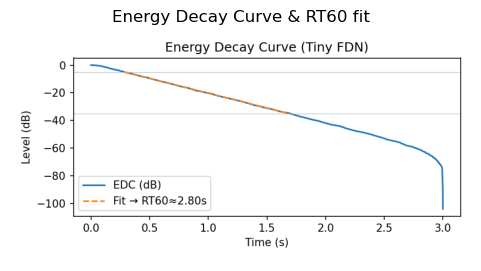

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("../eval/figs/fig_edc_rt60.png")
plt.figure(figsize=(6,3)); plt.imshow(img); plt.axis("off"); plt.title("Energy Decay Curve & RT60 fit"); plt.show()


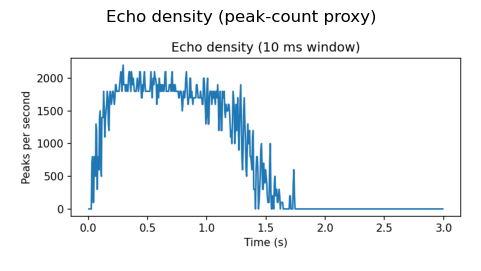

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("../eval/figs/fig_density.png")
plt.figure(figsize=(6,3)); plt.imshow(img); plt.axis("off"); plt.title("Echo density (peak-count proxy)"); plt.show()


## Why orthogonal feedback is a safe default (small-$N$)

If $\mathbf{F}$ is orthogonal ($\rho(\mathbf{F})=1$) and $|g_i|<1$, then the **overall loop gain** is strictly less than 1 in any direction because
$$
\|\mathbf{F}\,\mathbf{g}\,\mathbf{z}\|_2 \;\le\; \|\mathbf{g}\,\mathbf{z}\|_2 \;\le\; (\max_i |g_i|)\,\|\mathbf{z}\|_2.
$$
This bounds internal energy and makes $T_{60}$ control predictable. Small-order “metallic” effects then come from **delay periodicities** and **matrix eigenstructure**, not instability.


## Intuition: Hadamard vs Householder “color”

- **Hadamard** mixes via signed sums/differences; early recirculation creates structured interference patterns tied to the delay parities. This can emphasize narrow “combs” when delays are near-commensurate.
- **Householder** is a reflection: one global “sum” direction flips sign, the rest pass unchanged. It tends to equalize energy across lines each step, sometimes yielding quicker diffusion of early echoes (different feel, same stability).

These differences are subtle at large $N$, but at $N=4$ they are audible—great for this study.


In [6]:
import numpy as np

# Hadamard (orthonormal 4x4)
H = 0.5*np.array([[1,1,1,1],
                  [1,-1,1,-1],
                  [1,1,-1,-1],
                  [1,-1,-1,1]], dtype=float)

# Householder with v = [1,1,1,1]/2
v = (1/2.0)*np.ones((4,1))
HH = np.eye(4) - 2*(v@v.T)

np.set_printoptions(precision=3, suppress=True)
evals_H, _  = np.linalg.eig(H)
evals_HH,_  = np.linalg.eig(HH)
evals_H, evals_HH


(array([ 1., -1., -1.,  1.]), array([ 1., -1.,  1.,  1.]))

## Comparing designs (what we will measure)

For each $(\text{MatrixType}, \text{DelaySet})$ at a fixed $T_{60}$:

1. **EDC/RT60**: estimated $\widehat{\mathrm{RT60}}$ and early decay time (EDT).
2. **Echo density**: early $d(t)$ and **mixing time** $t_\mathrm{mix}$.
3. **Spectral “combiness”**: smoothed variance of $|H(e^{j\omega})|$ over bands or **spectral flatness measure** (SFM).
4. **Perceptual notes** on guitar/voice A/B clips (optional listening test).

Hypothesis: the **delay arithmetic** (Prime vs Spread) and **matrix class** interact to produce measurable differences in $d(t)$ and spectral variance at small $N$.


## What the prototype plugin implements (today)

- $N=4$ delay lines with two base sets at 48 kHz:
  - **Prime**: $\{1499, 2377, 3217, 4421\}$
  - **Spread**: $\{1103, 1733, 2549, 3917\}$
  Scaled by $f_s/48{,}000$ and an optional **Size** factor.
- Orthogonal feedback $\mathbf{F}$: **Hadamard** or **Householder** (toggle).
- Per-line gains $g_i(T_{60})=10^{-3 L_i/(T_{60} f_s)}$.
- Input injection $\alpha$ (small constant) and mean-tap wet output.
- Parameters: **RT60**, **Mix**, **MatrixType**, **DelaySet** (and internal Size).
- Minimal UI: two sliders (RT60/Mix), two toggles (Matrix/Delay), analytic decay sketch.


## Why near-commensurate delays sound “metallic” (math sketch)

With $N$ small, the **transfer function** from input to wet is a sum of $N$ comb-like contributions whose spacings are related to $1/L_i$. When ratios $L_i/L_j$ are near small rationals, partials **periodically line up**, yielding:
- slow build of echo density,
- narrow peaks/nulls (low spectral flatness),
- audible “ring” on percussive inputs.

By contrast, co-prime spreads de-align early echoes, increasing $d(t)$ and flattening the magnitude spectrum sooner.


## Next steps: diffusion targeting and safe time-variation

- **Echo-density controller**: adjust one safe DOF (e.g., a small delay swap or diffusion gain) to track a target $d(t)$ curve (“room/plate/natural”).  
- **Bounded modulation**: apply slow unitary rotations (Givens) with an **AM budget**: if rotation introduces amplitude-mod sidebands $$\pm f_m$$ near a tone, keep them below a threshold by limiting rotation rate.  
- **HF damping**: single one-pole per line for brightness control without harming stability.

All remain orthogonal/unitary, so stability proofs carry through.


## Reproducibility & FLOSS

- Codeberg repo: DPF plugin (CLAP/LV2/VST3) + JACK standalone.
- Exact build steps and parameters in `README.md`.
- Figures (`eval/figs/*.png`) are **reproducible** via Python scripts in `eval/scripts`.
- All code licensed permissively (MIT/Apache-2.0 dual), enabling inspection, reuse, and citation—aligning with best practices in reproducible audio research.

**How to reproduce** (short version):

```
make -j

load plugin in DAW, render IRs for the 2×2 Matrix×DelaySet grid (Mix=1.0)

python eval/scripts/compute_edc_rt60.py eval/signals/ir_...wav
python eval/scripts/echo_density.py eval/signals/ir_...wav
```

## Takeaways (from first experiments)

- **Orthogonal feedback** + **RT60-mapped per-line loss** gives a *stable*, math-guided tiny FDN.
- At small $N$, **matrix eigenstructure** and **delay arithmetic** are first-order determinants of “metallic” coloration.
- Our prototype already produces measurable **EDC** and **echo density** differences—setting up the core study.

*Next deliverables*: a 2×2 Matrix×DelaySet sweep with EDC/density plots and a small metrics table; then add diffusion-targeting and bounded modulation.
